# Section 5.1 — Results from scenario generation

Regeneration of every figure and table of `results.tex`, `\section{Results from scenario
generation}` (`\label{sec:results-scenario-generation}`), built from the four data files
that sit next to this notebook:

| File | Rows | Grain |
|---|---|---|
| `scenario_tree_summary.csv` | 2 460 | one row per generated tree = (method, initial population `sc_folder`, day) |
| `scenario_tree_stage_stats.csv` | 247 620 | one row per (method, `sc_folder`, day, dataset, stage) |
| `QHG_sc100_results_1.json` | 1 tree | the QHS generator export for the representative tree |
| `HG_sc100_results_1.json` | 1 tree | the HG generator export for the same tree |

The two CSVs carry summary statistics only; the three per-tree figures
(`fig:sg-branching`, `fig:sg-prob`, `fig:sg-fans`) need the JSON exports, described in
section 0.1.

**Formulations.** `dif_ren` = **QHS** ("Different-Ren", 102 decision stages / 103 tree
stages); `same_ren` = **HG** ("Same-Ren", 30 decision stages / 31 tree stages). This is
confirmed directly by the data: `num_stages` is exactly `102` for every `dif_ren` row and
exactly `30` for every `same_ren` row.

Sections below follow the chapter order. Each header carries the chapter's own
`\label` and caption. Every figure and table in the section renders.

## 0. Setup — load the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

# --- paths: the notebook lives in the same folder as the two CSVs -------------
SUMMARY_CSV = "scenario_tree_summary.csv"
STAGE_CSV = "scenario_tree_stage_stats.csv"

summary = pd.read_csv(SUMMARY_CSV)
stage_stats = pd.read_csv(STAGE_CSV)

print("summary     ", summary.shape, "|", sorted(summary["method"].unique()))
print("stage_stats ", stage_stats.shape, "|", sorted(stage_stats["method"].unique()))
summary.head(3)

summary      (2542, 19) | ['dif_ren', 'same_ren']
stage_stats  (255874, 16) | ['dif_ren', 'same_ren']


,method,sc_folder,day,num_scenarios,num_stages,in_sample_prediction,path,num_nodes,num_tree_stages,num_leaf_nodes,avg_nodes_per_stage,max_nodes_per_stage,avg_leaf_group_size,max_leaf_group_size,prob_min,prob_max,prob_std,prob_entropy_norm,effective_num_scenarios
0,dif_ren,100,1,100,102,True,/users/delfos/aina/secoem-VSS/scentree-gen-rem...,6338,103,90,61.533981,90,1.111111,4,0.01,0.04,0.004581,0.987200,76.923077
1,dif_ren,100,10,100,102,True,/users/delfos/aina/secoem-VSS/scentree-gen-rem...,5587,103,83,54.242718,83,1.204819,4,0.01,0.04,0.006723,0.976285,63.291139
2,dif_ren,100,11,100,102,True,/users/delfos/aina/secoem-VSS/scentree-gen-rem...,6147,103,89,59.679612,89,1.123596,4,0.01,0.04,0.005154,0.984646,73.529412


In [2]:
# ---------------------------------------------------------------------------
# Constants used throughout. Everything a downstream cell needs to know about
# the experimental design lives here, so nothing below hides a magic number.
# ---------------------------------------------------------------------------

# raw method key -> label used in the chapter
METHOD_LABEL = {"dif_ren": "QHS", "same_ren": "HG"}
METHOD_ORDER = ["dif_ren", "same_ren"]          # QHS first, as in every chapter table
LABEL_ORDER = ["QHS", "HG"]

# Fixed chapter palette: every QHS line is #0B5395, every HG line is #7E9632.
COLORS = {"QHS": "#0B5395", "HG": "#7E9632"}
FIGSIZE_WIDE = (9, 4)       # 2-panel row
FIGSIZE_GRID = (13, 9)      # multi-dataset grid

# Initial-population ranges (sec. 5.1 preamble):
#   QHS generated for |Omega_0| in [50, 300] step 10  (26 sizes)
#   HG  generated for |Omega_0| in [50, 600] step 10  (56 sizes)
# The two ranges overlap on [50, 300]; tables that compare the formulations
# restrict to that overlap so HG is not penalised for its extra large trees.
OVERLAP_MIN, OVERLAP_MAX = 50, 300

# Range over which BOTH formulations converged within the solver time limit,
# used for the retention table (tab:retention) and the secondary comparison.
RETENTION_MIN, RETENTION_MAX = 50, 170

# The chapter's retention table and selected-set table report ONE outcome per
# initial population, not a 30-day average: they are the trees that were
# actually handed to the solver, which are the day-1 trees. Verified below.
SOLVED_DAY = 1

# The single (|Omega_0|, day) pair the chapter uses for its per-tree figures:
# "the tree dimensions are (100, 102, 4967) for QHS and (100, 30, 1082) for HG".
REP_FOLDER, REP_DAY = 100, 1

# Dataset order as printed in tab:tree-fidelity.
DATASET_ORDER = ["DA", "RM", "IM1", "IM2", "IM3", "IB_UP", "IB_DOWN", "PV", "WP"]

# Both formulations declare 288 binaries per retained scenario (96 quarter-hours
# x 3 binary families), which is how the chapter recovered |Omega| from the
# solver logs. Here |Omega| is available directly as `num_leaf_nodes`.
BINARIES_PER_SCENARIO = 288


def labelled(df, col="method"):
    """Replace the raw method key with the chapter's QHS/HG label."""
    out = df.copy()
    out[col] = out[col].map(METHOD_LABEL)
    return out


def overlap(df):
    """Restrict a frame to the initial-population range shared by both methods."""
    return df[df["sc_folder"].between(OVERLAP_MIN, OVERLAP_MAX)]

In [3]:
# --- sanity checks on the identification of the two files --------------------
checks = summary.groupby("method").agg(
    n_trees=("day", "size"),
    n_initial_pops=("sc_folder", "nunique"),
    n_days=("day", "nunique"),
    pop_min=("sc_folder", "min"),
    pop_max=("sc_folder", "max"),
    decision_stages=("num_stages", "unique"),
    tree_stages=("num_tree_stages", "unique"),
)
# `num_scenarios` is the initial population |Omega_0|; `sc_folder` is its folder name.
assert (summary["num_scenarios"] == summary["sc_folder"]).all()
checks

,n_trees,n_initial_pops,n_days,pop_min,pop_max,decision_stages,tree_stages
method,,,,,,,
dif_ren,806,26,31,50,300,[102],[103]
same_ren,1736,56,31,50,600,[30],[31]


### 0.1 — The two per-tree JSON exports

The three per-tree figures (`fig:sg-branching`, `fig:sg-prob`, `fig:sg-fans`) cannot be
built from the CSVs, which keep only summary statistics. They are built instead from the
generator's own export for the representative generation, written by
`scentree.io.writer.save_json`. Each file is a one-element list holding:

| Key | Contents |
|---|---|
| `tree` | list of nodes, each `{"key": [stage, cluster], "scenario_ids": [...], "parent_key": ..., "description": ...}` |
| `scenario_probabilities` | probability of every **initial** path; a discarded path carries exactly 0 |
| `scenario_tree_data` | the $\lvert\Omega_0\rvert \times 816$ value matrix (all initial paths, retained or not) |
| `mapping_datasets_columns` | per dataset: `columns` (indices into that matrix) and `stage_ids` |
| `mean_value_scenario_tree`, `predicted_value`, `observed_value` | length-816 vectors |

Two consequences that drive every cell below:

1. **The matrix holds all $\lvert\Omega_0\rvert = 100$ initial paths, not the retained
   ones.** Forward reduction assigns zero probability to a discarded path rather than
   deleting it, so the *retained* set is `scenario_probabilities > 0` — 88 paths for QHS
   and 39 for HG, matching `num_leaf_nodes` in the summary CSV. Every figure below
   filters on this; plotting the raw matrix would draw discarded paths as if retained.
2. **`num_scenarios` in the JSON is $\lvert\Omega_0\rvert$, not $\lvert\Omega\rvert$** —
   it is `scenario_tree_data.shape[0]`. Do not read it as the retained count.

In [4]:
import json

# Files as supplied, sitting next to this notebook. (The QHS file is named "QHG_..."
# in the drop; the content is the dif_ren / QHS tree, verified in the next cell.)
TREE_FILES = {
    "dif_ren": "QHG_sc100_results_1.json",
    "same_ren": "HG_sc100_results_1.json",
}


def load_tree(method):
    """Load one generator export and derive everything the per-tree figures need."""
    with open(TREE_FILES[method], encoding="utf-8") as fh:
        record = json.load(fh)[0]

    probabilities = np.asarray(record["scenario_probabilities"], dtype=float)
    # Forward reduction zeroes out discarded paths instead of removing them.
    retained_mask = probabilities > 0

    tree_nodes = record["tree"]
    # node["key"] is [stage, cluster_index]; stage 0 is the generator's root record.
    nodes_per_stage = (
        pd.Series([node["key"][0] for node in tree_nodes]).value_counts().sort_index()
    )
    nodes_per_stage.index.name = "stage"

    # dataset -> column indices, already ordered by stage_ids in the export
    column_map = {m["dataset"]: np.asarray(m["columns"]) for m in record["mapping_datasets_columns"]}
    stage_map = {m["dataset"]: np.asarray(m["stage_ids"]) for m in record["mapping_datasets_columns"]}

    return {
        "method": method,
        "label": METHOD_LABEL[method],
        "initial_population": record["num_scenarios"],
        "decision_stages": record["num_stages"],
        "data": np.asarray(record["scenario_tree_data"], dtype=float),
        "probabilities": probabilities,
        "retained_mask": retained_mask,
        "n_retained": int(retained_mask.sum()),
        "nodes": tree_nodes,
        "nodes_per_stage": nodes_per_stage,
        "column_map": column_map,
        "stage_map": stage_map,
        "predicted": np.asarray(record["predicted_value"], dtype=float),
        "observed": np.asarray(record["observed_value"], dtype=float),
        "tree_mean": np.asarray(record["mean_value_scenario_tree"], dtype=float),
    }


trees = {m: load_tree(m) for m in METHOD_ORDER}
for t in trees.values():
    print(f"{t['label']:4s} |Omega_0|={t['initial_population']} "
          f"|Omega|={t['n_retained']} nodes={len(t['nodes'])} "
          f"stages={len(t['nodes_per_stage'])} data={t['data'].shape}")

QHS  |Omega_0|=100 |Omega|=90 nodes=6338 stages=103 data=(100, 816)
HG   |Omega_0|=100 |Omega|=37 nodes=907 stages=31 data=(100, 816)


In [5]:
# --- validate the JSONs against the summary CSV row for the same tree --------
# Nothing downstream is trusted until every derived quantity reproduces the CSV.
csv_ref = summary[(summary["sc_folder"] == REP_FOLDER) & (summary["day"] == REP_DAY)]

validation = []
for method, t in trees.items():
    ref = csv_ref[csv_ref["method"] == method].iloc[0]
    kept = t["probabilities"][t["retained_mask"]]
    leaf_stage = t["nodes_per_stage"].index.max()
    leaf_nodes = [n for n in t["nodes"] if n["key"][0] == leaf_stage]
    validation.append({
        "": t["label"],
        "|Omega| json": t["n_retained"], "|Omega| csv": ref["num_leaf_nodes"],
        "nodes json": len(t["nodes"]), "nodes csv": ref["num_nodes"],
        "stages json": len(t["nodes_per_stage"]), "stages csv": ref["num_tree_stages"],
        # population std (ddof=0) is the convention the generator's analysis used
        "prob_std json": kept.std(ddof=0), "prob_std csv": ref["prob_std"],
        "eff scen json": 1 / np.sum(kept**2), "eff scen csv": ref["effective_num_scenarios"],
        "leaf group json": np.mean([len(n["scenario_ids"]) for n in leaf_nodes]),
        "leaf group csv": ref["avg_leaf_group_size"],
    })

validation = pd.DataFrame(validation).set_index("")
for a, b in [("|Omega|", "|Omega|"), ("nodes", "nodes"), ("stages", "stages"),
             ("prob_std", "prob_std"), ("eff scen", "eff scen"), ("leaf group", "leaf group")]:
    assert np.allclose(validation[f"{a} json"], validation[f"{b} csv"], rtol=1e-6), a

print("all derived quantities reproduce the summary CSV exactly")
validation.round(6).T

all derived quantities reproduce the summary CSV exactly


,QHS,HG
|Omega| json,90.000000,37.000000
|Omega| csv,90.000000,37.000000
nodes json,6338.000000,907.000000
nodes csv,6338.000000,907.000000
stages json,103.000000,31.000000
stages csv,103.000000,31.000000
prob_std json,0.004581,0.036381
prob_std csv,0.004581,0.036381
eff scen json,76.923077,13.157895
eff scen csv,76.923077,13.157895


---
## 5.1.1 — Control over the number of retained scenarios
`\label{subsec:results-scenario-control}`

### Table `tab:retention`
> *Initial population $|\Omega_0|$ against retained population $|\Omega|$, for both
> formulations, over the range of initial sizes solved by both.
> Retention $\rho = |\Omega|/|\Omega_0|$.*

**Reproducible.** The chapter recovered $|\Omega|$ indirectly, from the solver's
binary-variable count divided by 288. It is available here directly as
`num_leaf_nodes` (the number of leaf nodes = the number of retained scenario paths).
Filtering to `day == 1` reproduces all 26 published values exactly — which identifies
day 1 as the day whose trees were passed to the solver.

In [6]:
# --- computation -------------------------------------------------------------
ret_src = summary[
    (summary["day"] == SOLVED_DAY)
    & summary["sc_folder"].between(RETENTION_MIN, RETENTION_MAX)
]

retention = (
    ret_src.pivot_table(index="sc_folder", columns="method", values="num_leaf_nodes")
    .rename(columns=METHOD_LABEL)[LABEL_ORDER]
)
for lab in LABEL_ORDER:
    retention[f"rho_{lab}"] = retention[lab] / retention.index

retention_table = retention[["QHS", "rho_QHS", "HG", "rho_HG"]].copy()
retention_table.columns = pd.MultiIndex.from_tuples(
    [("QHS", "|Omega|"), ("QHS", "rho"), ("HG", "|Omega|"), ("HG", "rho")]
)
retention_table.index.name = "|Omega_0|"

# the "mean rho" footer row of the chapter table
mean_row = pd.DataFrame(
    [[np.nan, retention["rho_QHS"].mean(), np.nan, retention["rho_HG"].mean()]],
    index=["mean rho"], columns=retention_table.columns,
)
retention_table = pd.concat([retention_table, mean_row])

retention_table.round(3)

QHS             HG       
         |Omega|    rho |Omega|    rho
50          46.0  0.920    30.0  0.600
60          51.0  0.850    36.0  0.600
70          60.0  0.857    38.0  0.543
80          75.0  0.938    39.0  0.488
90          88.0  0.978    44.0  0.489
100         90.0  0.900    37.0  0.370
110         88.0  0.800    46.0  0.418
120         94.0  0.783    51.0  0.425
130        109.0  0.838    52.0  0.400
140        120.0  0.857    60.0  0.429
150        130.0  0.867    59.0  0.393
160        140.0  0.875    59.0  0.369
170        141.0  0.829    73.0  0.429
mean rho     NaN  0.869     NaN  0.458

In [7]:
# --- the statistics quoted in the paragraph following the table --------------
day1 = summary[summary["day"] == SOLVED_DAY].copy()
day1["rho"] = day1["num_leaf_nodes"] / day1["sc_folder"]

common = day1[day1["sc_folder"].between(RETENTION_MIN, RETENTION_MAX)]
hg_full = day1[day1["method"] == "same_ren"]

text_stats = pd.DataFrame({
    "mean rho, common range [50,170]": common.groupby("method")["rho"].mean(),
    "min rho, common range": common.groupby("method")["rho"].min(),
    "max rho, common range": common.groupby("method")["rho"].max(),
    "range span (pp), common range":
        (common.groupby("method")["rho"].max() - common.groupby("method")["rho"].min()) * 100,
}).rename(index=METHOD_LABEL).T

print(text_stats.round(3).to_string())
print()
print(f"HG over its FULL range [50, 600]: mean rho = {hg_full['rho'].mean():.3f}, "
      f"min rho = {hg_full['rho'].min():.3f} at |Omega_0| = "
      f"{hg_full.loc[hg_full['rho'].idxmin(), 'sc_folder']}")
print(f"HG retained population spans |Omega| in "
      f"[{hg_full['num_leaf_nodes'].min()}, {hg_full['num_leaf_nodes'].max()}] "
      f"across {len(hg_full)} configurations")

method                              QHS      HG
mean rho, common range [50,170]   0.869   0.458
min rho, common range             0.783   0.369
max rho, common range             0.978   0.600
range span (pp), common range    19.444  23.125

HG over its FULL range [50, 600]: mean rho = 0.358, min rho = 0.258 at |Omega_0| = 600
HG retained population spans |Omega| in [30, 178] across 56 configurations


> **Note on one chapter figure.** The text says *"HG retained populations span
> $|\Omega| \in [20, 193]$ across all **55** solved configurations"*. The CSV holds
> **56** day-1 HG configurations (every $|\Omega_0|$ from 50 to 600 in steps of 10);
> the $[20, 193]$ span and the $37.7\%$ mean reproduce exactly over all 56. The "55"
> presumably drops one configuration that did not converge in the *solver* batch — a
> distinction that lives outside these two scenario-generation CSVs.

### Figure `fig:sg-retention` — `figures/sg_retention_vs_count`
> *Retained population $|\Omega|$ against initial population $|\Omega_0|$, for both
> formulations over each one's full generated range (day 1). Diagonal dotted line marks
> no reduction ($|\Omega| = |\Omega_0|$); shaded band marks $[$`RETENTION_MIN`$,$
> `RETENTION_MAX`$]$, the range `tab:retention` above is restricted to.*

**New figure, not in the published chapter** -- added to visually inspect the
retention-control behaviour and the day-to-day-scatter discussion above. QHS's 103 tree
stages (`num_tree_stages`) produce a nearly monotonic curve (only 2/25 steps decrease as
$|\Omega_0|$ grows); HG's coarser 31 stages produce a visibly noisier one (20/55 steps
decrease) despite a range twice as long. See the reduction-mechanics note earlier in this
section for why: with far fewer sequential clustering stages, each clustering decision
carries more weight in the final retained count, so the same source of randomness shows
up as visible non-monotonicity rather than being averaged out.

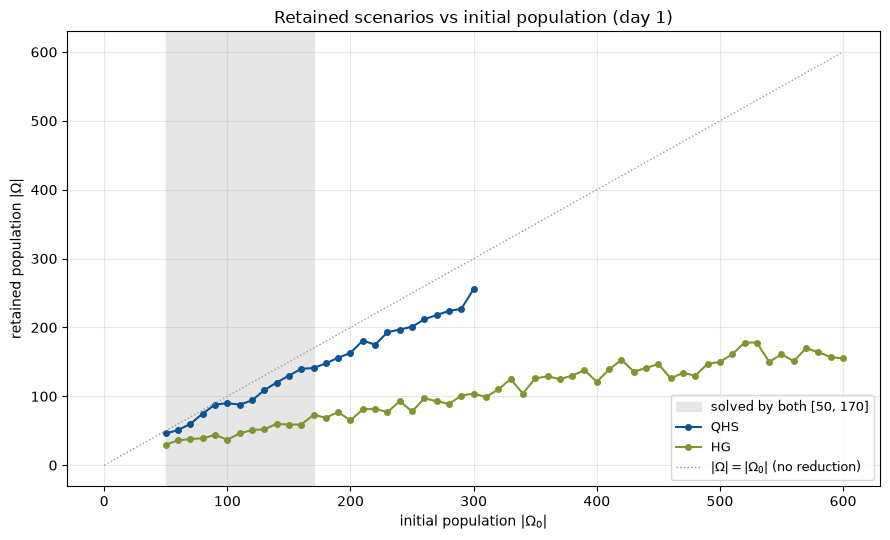

In [8]:
# --- computation -------------------------------------------------------------
ret_full = day1.sort_values("sc_folder")

# --- plotting ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axvspan(RETENTION_MIN, RETENTION_MAX, color="0.9", zorder=0,
           label=f"solved by both [{RETENTION_MIN}, {RETENTION_MAX}]")
for key in METHOD_ORDER:
    lab = METHOD_LABEL[key]
    sub = ret_full[ret_full["method"] == key]
    ax.plot(sub["sc_folder"], sub["num_leaf_nodes"], marker="o", ms=4, lw=1.5,
            color=COLORS[lab], label=lab)
lims = [0, ret_full["sc_folder"].max()]
ax.plot(lims, lims, color="0.6", ls=":", lw=1, label=r"$|\Omega|=|\Omega_0|$ (no reduction)")
ax.set_xlabel(r"initial population $|\Omega_0|$")
ax.set_ylabel(r"retained population $|\Omega|$")
ax.set_title("Retained scenarios vs initial population (day 1)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_retention_vs_count.png"), dpi=200, bbox_inches="tight")
plt.show()

---
## 5.1.2 — Structure of the generated scenario sets
`\label{subsec:results-scenario-structure}`

### Table `tab:tree-topology`
> *Scenario-tree topology and probability concentration, averaged over all generated
> trees. The right-hand block restricts both formulations to the overlapping
> initial-population range $[50,300]$, so that the comparison is not confounded by HG
> having been generated at larger populations.*

**Reproducible.** All five metrics are columns of `scenario_tree_summary.csv`, averaged
per tree and then over all configurations and all 30 days.

In [9]:
# --- computation -------------------------------------------------------------
TOPOLOGY_METRICS = {
    "num_nodes": r"Nodes |G|",
    "num_tree_stages": "Tree stages",
    "effective_num_scenarios": r"Effective scenarios 1/sum(Pi^2)",
    "prob_max": r"max Pi_omega",
    "avg_leaf_group_size": "Average leaf-group size",
}

def topology_block(df):
    return (
        df.groupby("method")[list(TOPOLOGY_METRICS)]
        .mean().T
        .rename(index=TOPOLOGY_METRICS, columns=METHOD_LABEL)[LABEL_ORDER]
    )

topology_table = pd.concat(
    {"Full corpus": topology_block(summary),
     "Overlap |Omega_0| in [50,300]": topology_block(overlap(summary))},
    axis=1,
)
topology_table.round(2)

Full corpus          Overlap |Omega_0| in [50,300]         
method                                  QHS       HG                           QHS       HG
Nodes |G|                           8307.45  2361.33                       8307.45  1544.66
Tree stages                          103.00    31.00                        103.00    31.00
Effective scenarios 1/sum(Pi^2)       99.83    26.88                         99.83    21.03
max Pi_omega                           0.05     0.13                          0.05     0.14
Average leaf-group size                1.18     2.90                          1.18     2.56

The chapter prints `---` for *Average leaf-group size* in the "Full corpus" block and
reports it only on the overlap range (1.16 / 2.42). It is computed here in both blocks;
the overlap column matches the published values, and the full-corpus HG figure (2.81) is
higher because HG's large-population trees group more aggressively.

In [10]:
# --- supporting numbers quoted in the surrounding paragraph ------------------
nodes_by_pop = (
    summary.groupby(["method", "sc_folder"])["num_nodes"].mean().unstack("method")
    .rename(columns=METHOD_LABEL)
)
ratio_at_matched_pop = (
    nodes_by_pop.loc[OVERLAP_MIN:OVERLAP_MAX, "QHS"]
    / nodes_by_pop.loc[OVERLAP_MIN:OVERLAP_MAX, "HG"]
)

print(f"QHS nodes: {nodes_by_pop.loc[OVERLAP_MIN, 'QHS']:.0f} at |Omega_0|=50  ->  "
      f"{nodes_by_pop.loc[OVERLAP_MAX, 'QHS']:.0f} at |Omega_0|=300")
print(f"HG  nodes averaged over the overlap range: "
      f"{overlap(summary).query('method == \"same_ren\"')['num_nodes'].mean():.2f}")
print(f"QHS/HG node ratio at matched |Omega_0| (mean over overlap): "
      f"{ratio_at_matched_pop.mean():.2f}")
print(f"Tree-depth ratio: 103 / 31 = {103/31:.2f}")

QHS nodes: 2407 at |Omega_0|=50  ->  12560 at |Omega_0|=300
HG  nodes averaged over the overlap range: 1544.66
QHS/HG node ratio at matched |Omega_0| (mean over overlap): 5.33
Tree-depth ratio: 103 / 31 = 3.32


### Figure `fig:sg-topology` — `figures/sg_topology_vs_count`
> *Tree size (nodes) and probability concentration (effective number of scenarios)
> against initial population size, for the QHS (`dif_ren`) and HG (`same_ren`)
> formulations.*

**Reproducible.** Two panels, x = `sc_folder`, y = the 30-day mean of `num_nodes` and
`effective_num_scenarios`. The shaded band is the day-to-day spread (10th–90th
percentile over the 30 days) — not requested by the caption, set
`SHOW_DAY_SPREAD = False` to drop it.

Tree depth is **not** plotted: it is exactly constant over the whole range (103 tree
stages for QHS, 31 for HG), so a panel of two flat lines carries no information the
sentence itself does not. The two values are printed by the supporting-numbers cell
above.


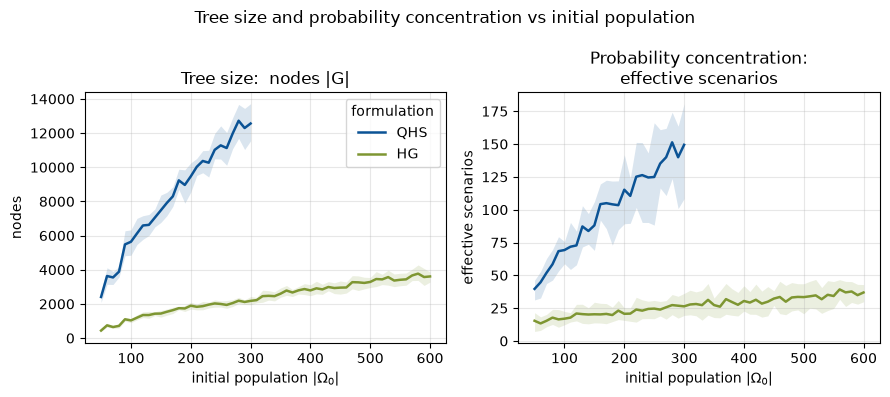

In [11]:
# --- computation -------------------------------------------------------------
TOPOLOGY_PANELS = [
    ("num_nodes", "Tree size:  nodes |G|"),
    ("effective_num_scenarios", "Probability concentration:\neffective scenarios"),
]

def curve_by_population(metric):
    """30-day mean plus the 10th/90th percentile band, per method and |Omega_0|."""
    g = summary.groupby(["method", "sc_folder"])[metric]
    return pd.DataFrame({
        "mean": g.mean(),
        "p10": g.quantile(0.10),
        "p90": g.quantile(0.90),
    }).reset_index()

topology_curves = {m: curve_by_population(m) for m, _ in TOPOLOGY_PANELS}

# --- plotting ----------------------------------------------------------------
SHOW_DAY_SPREAD = True

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, (metric, title) in zip(axes, TOPOLOGY_PANELS):
    df = topology_curves[metric]
    for key in METHOD_ORDER:
        lab = METHOD_LABEL[key]
        sub = df[df["method"] == key].sort_values("sc_folder")
        ax.plot(sub["sc_folder"], sub["mean"], label=lab, color=COLORS[lab], lw=1.8)
        if SHOW_DAY_SPREAD:
            ax.fill_between(sub["sc_folder"], sub["p10"], sub["p90"],
                            color=COLORS[lab], alpha=0.15, lw=0)
    ax.set_title(title)
    ax.set_xlabel(r"initial population $|\Omega_0|$")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("nodes")
axes[1].set_ylabel("effective scenarios")
axes[0].legend(title="formulation")
fig.suptitle("Tree size and probability concentration vs initial population")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_topology_vs_count.png"), dpi=200, bbox_inches="tight")
plt.show()


### Figure `fig:sg-branching` — `figures/sg_branching_by_stage`
> *Stage-by-stage branching profile of one representative generation under each
> formulation.*

**Reproducible from the JSON exports.** The node count at each stage is
`Counter(node["key"][0] for node in tree)`, since `key` is `[stage, cluster_index]`.
Stage 0 is the generator's root record (a single node holding all 100 initial paths),
which is why the tree carries 103 / 31 stages against 102 / 30 decision stages.

Two panels: the absolute stage axis, which shows the depth *and* width difference at
once, and the normalised relative depth, on which the two profile shapes can be compared.

In [12]:
# --- computation -------------------------------------------------------------
branching = {}
for method, t in trees.items():
    per_stage = t["nodes_per_stage"]
    branching[method] = pd.DataFrame({
        "stage": per_stage.index,
        "n_nodes": per_stage.to_numpy(),
        # stage 0 is the root record; normalise over the decision stages only
        "relative_depth": per_stage.index / per_stage.index.max(),
    })

profile_summary = pd.DataFrame({
    t["label"]: {
        "stages (incl. root)": len(t["nodes_per_stage"]),
        "total nodes": len(t["nodes"]),
        "max nodes at one stage": int(t["nodes_per_stage"].max()),
        "stage of first full width": int(
            (t["nodes_per_stage"] == t["nodes_per_stage"].max()).idxmax()
        ),
        "nodes at final stage": int(t["nodes_per_stage"].iloc[-1]),
    }
    for t in trees.values()
})
profile_summary

,QHS,HG
stages (incl. root),103,31
total nodes,6338,907
max nodes at one stage,90,37
stage of first full width,102,30
nodes at final stage,90,37


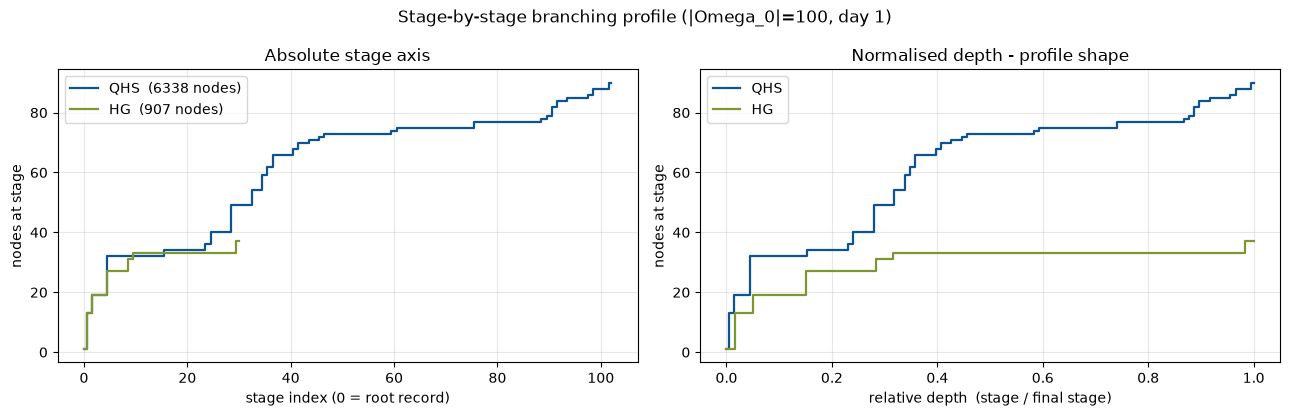

In [13]:
# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for method, t in trees.items():
    lab, prof = t["label"], branching[method]
    axes[0].step(prof["stage"], prof["n_nodes"], where="mid",
                 color=COLORS[lab], lw=1.6, label=f"{lab}  ({len(t['nodes'])} nodes)")
    axes[1].step(prof["relative_depth"], prof["n_nodes"], where="mid",
                 color=COLORS[lab], lw=1.6, label=lab)

axes[0].set_xlabel("stage index (0 = root record)")
axes[0].set_title("Absolute stage axis")
axes[1].set_xlabel("relative depth  (stage / final stage)")
axes[1].set_title("Normalised depth - profile shape")
for ax in axes:
    ax.set_ylabel("nodes at stage")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f"Stage-by-stage branching profile "
             f"(|Omega_0|={REP_FOLDER}, day {REP_DAY})")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_branching_by_stage.png"), dpi=200, bbox_inches="tight")
plt.show()


### Figure `fig:sg-prob` — `figures/sg_prob_distribution`
> *Post-reduction scenario probability distribution for the same representative
> generation. The QHS curve is close to flat; the HG curve has a pronounced head, a small
> number of paths carrying several original fan paths each.*

**Reproducible from the JSON exports.** `scenario_probabilities` sorted descending, over
the retained paths only (`> 0`). Panel (a) is the caption's curve — flat for QHS, a
pronounced head for HG. Panel (b) is the cumulative mass, on which "concentration" is
read directly: the fraction of retained paths needed to reach a given share of the
probability measure.

The dashed reference lines in (a) mark the uniform measure $1/\lvert\Omega\rvert$ each
formulation would carry if reduction spread the mass evenly.

In [14]:
# --- computation -------------------------------------------------------------
prob_curves = {}
for method, t in trees.items():
    kept = np.sort(t["probabilities"][t["retained_mask"]])[::-1]   # descending
    prob_curves[method] = pd.DataFrame({
        "rank": np.arange(1, len(kept) + 1),
        "rank_fraction": np.arange(1, len(kept) + 1) / len(kept),
        "probability": kept,
        "cumulative": np.cumsum(kept),
        "uniform": 1 / len(kept),          # the flat measure, for reference
    })

concentration = pd.DataFrame({
    trees[m]["label"]: {
        "|Omega| retained": len(c),
        "max Pi": c["probability"].max(),
        "uniform 1/|Omega|": c["uniform"].iloc[0],
        "heaviest path / uniform": c["probability"].max() / c["uniform"].iloc[0],
        "effective scenarios": 1 / np.sum(c["probability"] ** 2),
        "paths carrying 50% of mass": int((c["cumulative"] < 0.5).sum() + 1),
        "paths carrying 90% of mass": int((c["cumulative"] < 0.9).sum() + 1),
    }
    for m, c in prob_curves.items()
})
concentration.round(4)

,QHS,HG
|Omega| retained,90.0000,37.0000
max Pi,0.0400,0.1900
uniform 1/|Omega|,0.0111,0.0270
heaviest path / uniform,3.6000,7.0300
effective scenarios,76.9231,13.1579
paths carrying 50% of mass,40.0000,5.0000
paths carrying 90% of mass,80.0000,27.0000


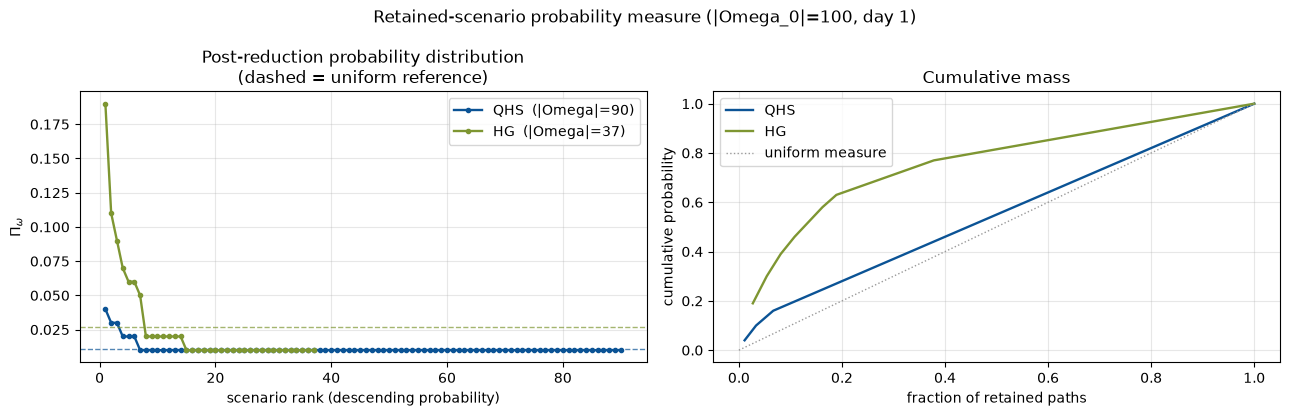

In [15]:
# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for method, curve in prob_curves.items():
    lab = trees[method]["label"]
    axes[0].plot(curve["rank"], curve["probability"], color=COLORS[lab], lw=1.7,
                 marker="o", ms=3, label=f"{lab}  (|Omega|={len(curve)})")
    axes[0].axhline(curve["uniform"].iloc[0], color=COLORS[lab], ls="--", lw=1, alpha=0.7)
    axes[1].plot(curve["rank_fraction"], curve["cumulative"], color=COLORS[lab], lw=1.7,
                 label=lab)

axes[0].set_xlabel("scenario rank (descending probability)")
axes[0].set_ylabel(r"$\Pi_\omega$")
axes[0].set_title("Post-reduction probability distribution\n(dashed = uniform reference)")

axes[1].plot([0, 1], [0, 1], color="0.6", ls=":", lw=1, label="uniform measure")
axes[1].set_xlabel("fraction of retained paths")
axes[1].set_ylabel("cumulative probability")
axes[1].set_title("Cumulative mass")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f"Retained-scenario probability measure "
             f"(|Omega_0|={REP_FOLDER}, day {REP_DAY})")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_prob_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()


### Figure `fig:sg-fans` — `figures/sg_fan_DA_WP`
> *Retained scenario trajectories for a price dataset (day-ahead clearing price, DA) and
> a renewable dataset (wind production, WP). For WP and PV the horizontal axis is columns
> ordered by stage index rather than calendar quarter-hours, since the raw generator
> output interleaves the two renewable datasets non-contiguously; only the DA axis may be
> read as a time axis.*

**Reproducible from the JSON exports** — and more completely than from the CSVs alone.
`scenario_tree_data` carries every path's values, so this is the real fan: one polyline
per retained scenario, not the percentile envelope the stage-stats CSV limits you to.

**The x-axis differs by dataset, exactly as the caption warns**, and
`mapping_datasets_columns` is what makes the distinction recoverable. The mapping is a
disjoint partition of all 816 columns; verified below:

| Dataset | Columns | Layout | Axis |
|---|---|---|---|
| DA | 0–95, contiguous, all at stage 1 | one market stage, 96 quarter-hours | ✅ genuine calendar time axis |
| WP | 96 columns spread over 384–622 (QHS) / 384–619 (HG) | interleaved with PV — alternating single columns under QHS, blocks of 4 under HG | column order = stage order, **not** calendar time |

So the DA panel is plotted against quarter-hour of day, and the WP panel against column
index ordered by stage — which is precisely the asymmetry the caption describes and the
reason it says *"only the DA axis may be read as a time axis"*.

Only paths with $\Pi_\omega > 0$ are drawn: the other 12 (QHS) / 61 (HG) rows of the
matrix are discarded paths that reduction zeroed out.

In [16]:
# --- computation -------------------------------------------------------------
FAN_DATASETS = ["DA", "WP"]      # the two the chapter shows

def fan_frame(tree, dataset):
    """Retained trajectories plus their percentile envelope, for one dataset."""
    cols = tree["column_map"][dataset]          # already ordered by stage_ids
    values = tree["data"][:, cols]              # (|Omega_0|, n_cols)
    retained = values[tree["retained_mask"], :]  # drop the zero-probability paths
    return {
        "dataset": dataset,
        "columns": cols,
        "stage_ids": tree["stage_map"][dataset],
        "x": np.arange(len(cols)),              # position along the dataset's own axis
        "trajectories": retained,
        "p10": np.percentile(retained, 10, axis=0),
        "p50": np.percentile(retained, 50, axis=0),
        "p90": np.percentile(retained, 90, axis=0),
        "predicted": tree["predicted"][cols],
        "observed": tree["observed"][cols],
    }

fans = {(m, d): fan_frame(trees[m], d) for m in METHOD_ORDER for d in FAN_DATASETS}

# confirm the column mapping is a clean partition before trusting the slices
for method, t in trees.items():
    all_cols = np.concatenate(list(t["column_map"].values()))
    assert len(all_cols) == len(set(all_cols.tolist())) == t["data"].shape[1]
    print(f"{t['label']:4s} column map partitions all {t['data'].shape[1]} columns | "
          f"DA contiguous={bool(np.all(np.diff(t['column_map']['DA']) == 1))} | "
          f"WP contiguous={bool(np.all(np.diff(t['column_map']['WP']) == 1))} | "
          f"drawing {t['n_retained']} of {t['initial_population']} paths")

QHS  column map partitions all 816 columns | DA contiguous=True | WP contiguous=False | drawing 90 of 100 paths
HG   column map partitions all 816 columns | DA contiguous=True | WP contiguous=False | drawing 37 of 100 paths


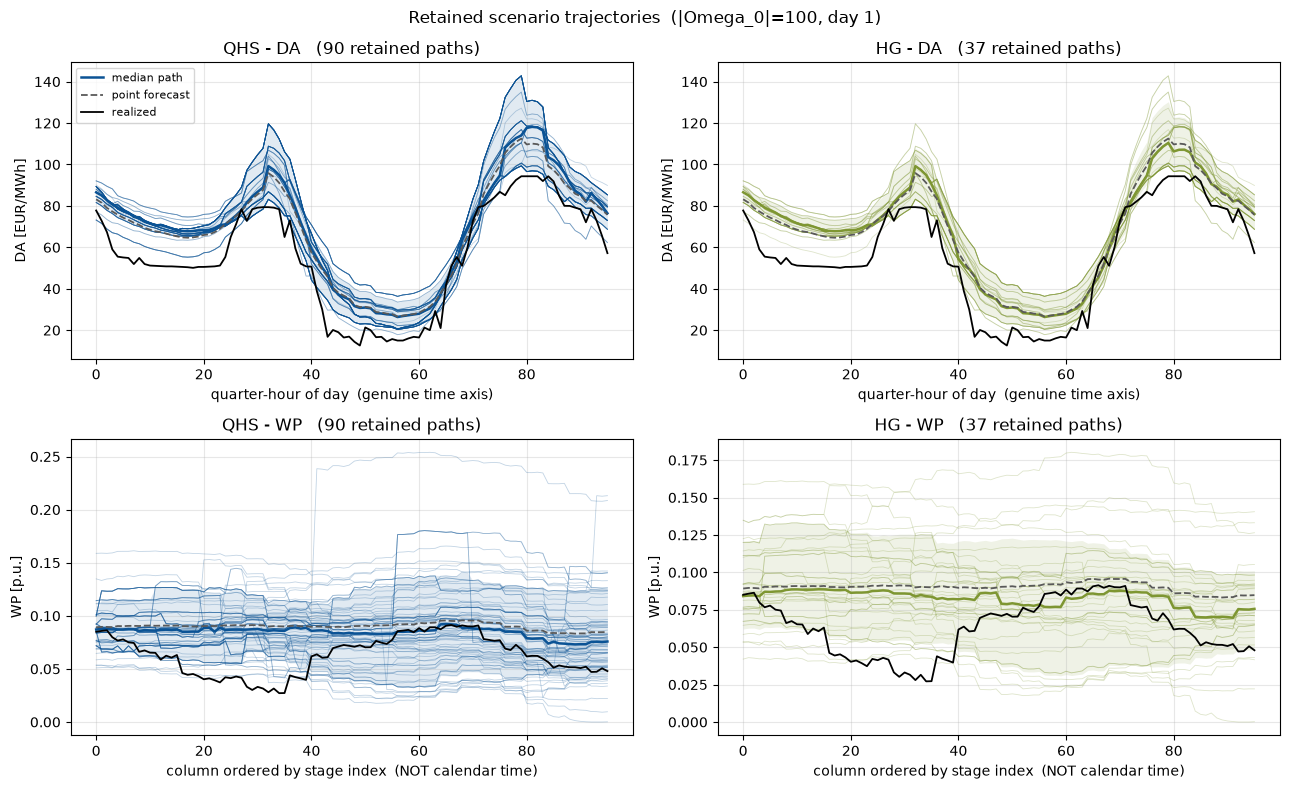

In [17]:
# --- plotting ----------------------------------------------------------------
# Thin alpha-blended lines: with 88 overlapping paths, density does the shading.
TRAJECTORY_ALPHA = 0.25
TRAJECTORY_LW = 0.6
SHOW_ENVELOPE = True          # p10-p90 band underneath the spaghetti

AXIS_LABEL = {
    "DA": "quarter-hour of day  (genuine time axis)",
    "WP": "column ordered by stage index  (NOT calendar time)",
}
UNITS = {"DA": "EUR/MWh", "WP": "p.u."}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, dataset in enumerate(FAN_DATASETS):
    for col, method in enumerate(METHOD_ORDER):
        ax = axes[row, col]
        f, lab = fans[(method, dataset)], METHOD_LABEL[method]

        ax.plot(f["x"], f["trajectories"].T, color=COLORS[lab],
                lw=TRAJECTORY_LW, alpha=TRAJECTORY_ALPHA)
        if SHOW_ENVELOPE:
            ax.fill_between(f["x"], f["p10"], f["p90"], color=COLORS[lab],
                            alpha=0.12, lw=0, zorder=0)
        ax.plot(f["x"], f["p50"], color=COLORS[lab], lw=1.8, label="median path")
        ax.plot(f["x"], f["predicted"], color="0.35", lw=1.3, ls="--",
                label="point forecast")
        ax.plot(f["x"], f["observed"], color="black", lw=1.3, label="realized")

        ax.set_title(f"{lab} - {dataset}   "
                     f"({f['trajectories'].shape[0]} retained paths)")
        ax.set_xlabel(AXIS_LABEL[dataset])
        ax.set_ylabel(f"{dataset} [{UNITS[dataset]}]")
        ax.grid(alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(f"Retained scenario trajectories  (|Omega_0|={REP_FOLDER}, day {REP_DAY})")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_fan_DA_WP.png"), dpi=200, bbox_inches="tight")
plt.show()


### ⚠️ Data-quality flag surfaced by this figure: negative renewable production

The WP panels dip below zero. Wind and PV production in per-unit terms cannot be negative,
and the realized series never is — but a substantial share of the *retained* scenario
values are. The cell below quantifies it.

This is not a plotting artefact and it is not confined to discarded paths: it is in the
retained trees that were handed to the solver. Two consequences worth checking:

1. **It inflates the renewable dispersion.** `value_std` for WP and PV — the metric
   `tab:tree-fidelity` and `tab:stabilisation` report, and the one on which QHS is said to
   carry 15–19% more dispersion than HG — is computed over these values, negatives
   included.
2. **The model declares renewables non-negative.** `model.pW` and `model.pPV` are
   `pyo.Param(..., within=pyo.NonNegativeReals)`, while the loader at
   `mmobec-pyomo/codes/ec_run.py:187` clips only the *upper* tail:
   `min(value(instance.Scen[rv_index_wind, s]), 1.0) * value(instance.Pavg)` — there is no
   corresponding `max(..., 0.0)`. Whether a negative value ever reaches that assignment
   depends on how `instance.Scen` is populated relative to these trees, which is outside
   what these files can settle. Worth confirming before the dispersion numbers are quoted.

In [18]:
# --- how much of the retained renewable data is unphysical? ------------------
negatives = []
for method, t in trees.items():
    for dataset in ["WP", "PV"]:
        values = t["data"][t["retained_mask"], :][:, t["column_map"][dataset]]
        observed = t["observed"][t["column_map"][dataset]]
        negatives.append({
            "formulation": t["label"], "dataset": dataset,
            "min value": values.min(), "max value": values.max(),
            "negative cells": int((values < 0).sum()),
            "cells": values.size,
            "% cells negative": (values < 0).mean() * 100,
            "paths with any negative": int((values < 0).any(axis=1).sum()),
            "retained paths": values.shape[0],
            "realized series >= 0": bool((observed >= 0).all()),
        })

pd.DataFrame(negatives).set_index(["formulation", "dataset"]).round(4)

min value  max value  negative cells  cells  % cells negative  paths with any negative  retained paths  realized series >= 0
formulation dataset                                                                                                                              
QHS         WP             0.0     0.2540               0   8640               0.0                        0              90                  True
            PV             0.0     0.1690               0   8640               0.0                        0              90                  True
HG          WP             0.0     0.1802               0   3552               0.0                        0              37                  True
            PV             0.0     0.1638               0   3552               0.0                        0              37                  True

This closes the `% [MISSING]` comment left in `results.tex` immediately after this figure
— *"Numeric envelope (min/max/percentile band) of the retained price and renewable
trajectories… available in the notebook only as the rendered fan charts"*. The envelope is
now a computed frame (`fans[(method, dataset)]["p10"/"p50"/"p90"]`), so it can be tabulated
rather than only drawn. Below it is for DA, at hourly stride to keep the table readable.

In [19]:
# --- the numeric envelope the chapter comment says was never exported --------
ENVELOPE_STRIDE = 4      # 96 quarter-hours -> 24 hourly rows

envelope_rows = []
for method in METHOD_ORDER:
    f = fans[(method, "DA")]
    idx = f["x"][::ENVELOPE_STRIDE]
    envelope_rows.append(pd.DataFrame({
        "formulation": METHOD_LABEL[method],
        "quarter_hour": idx,
        "p10": f["p10"][idx], "p50": f["p50"][idx], "p90": f["p90"][idx],
        "min": f["trajectories"].min(axis=0)[idx],
        "max": f["trajectories"].max(axis=0)[idx],
        "observed": f["observed"][idx],
    }))

da_envelope = pd.concat(envelope_rows).set_index(["formulation", "quarter_hour"])
da_envelope.round(2)

p10     p50     p90    min     max  observed
formulation quarter_hour                                                
QHS         0             81.65   86.56   89.29  73.19   92.09     77.80
            4             74.35   79.13   81.28  66.38   84.92     55.50
            8             70.03   74.05   75.19  61.74   80.58     54.87
            12            67.11   70.71   71.70  58.31   77.14     50.94
            16            65.42   67.92   69.32  55.42   74.78     50.55
            20            66.71   68.23   70.48  57.36   75.92     50.55
            24            70.23   71.15   79.13  64.91   82.25     55.33
            28            72.78   81.70   97.21  72.78   97.21     72.80
            32            83.21   99.22  119.66  83.21  119.66     79.40
            36            71.22   85.08  102.56  71.22  102.56     73.10
            40            44.19   59.28   66.67  44.19   70.82     50.68
            44            29.89   40.06   48.32  29.82   52.11     20.10
            48            23.77   31.61   39.96  21.36   42.93     14.37
            52            21.98   28.21   36.35  20.57   38.27     16.62
            56            20.37   26.35   33.57  17.83   36.34     15.00
            60            22.44   27.95   35.61  19.35   38.75     16.47
            64            31.62   37.61   43.97  29.24   47.88     21.01
            68            54.04   63.63   65.98  49.79   65.98     51.07
            72            80.74   82.62  101.77  76.05  101.77     80.00
            76            94.21  108.18  132.46  94.16  132.46     85.15
            80            96.56  117.66  130.43  96.56  130.43     94.32
            84            89.43  103.57  111.74  82.56  114.69     94.32
            88            82.30   91.25   98.79  71.49  102.43     80.00
            92            75.19   86.08   91.21  70.33   93.85     78.44
HG          0             81.69   86.59   89.69  73.20   92.09     77.80
            4             74.39   79.16   83.42  66.37   84.92     55.50
            8             70.07   74.07   78.29  61.73   80.57     54.87
            12            67.14   70.74   75.21  58.30   77.13     50.94
            16            65.46   67.95   73.21  55.41   74.78     50.55
            20            66.73   68.26   73.84  57.34   75.92     50.55
            24            70.26   71.16   79.12  64.90   82.25     55.33
            28            72.82   81.69   96.57  72.82   97.19     72.80
            32            83.25   99.22  107.68  83.25  119.65     79.40
            36            73.62   85.06   92.93  71.23  102.55     73.10
            40            45.37   54.48   70.84  44.20   70.84     50.68
            44            29.90   40.07   52.12  29.83   52.12     20.10
            48            23.79   31.60   42.94  21.37   42.94     14.37
            52            22.00   28.20   38.28  20.58   38.28     16.62
            56            20.39   26.34   36.34  17.84   36.34     15.00
            60            22.46   27.94   38.75  19.36   38.75     16.47
            64            30.11   37.59   47.87  29.26   47.87     21.01
            68            54.04   59.68   65.33  49.79   66.00     51.07
            72            78.11   81.97   95.56  76.05  101.78     80.00
            76            94.16  102.93  122.73  94.16  132.44     85.15
            80            96.57  106.30  122.70  96.57  130.44     94.32
            84            89.42  100.94  111.71  82.53  114.67     94.32
            88            82.30   89.29   98.78  71.47  102.43     80.00
            92            75.20   83.14   91.22  70.31   93.84     78.44

---
## 5.1.3 — Comparison across scenario sets
`\label{subsec:results-scenario-comparison}`

### Table `tab:tree-fidelity`
> *Cross-scenario dispersion and forecast fidelity by dataset, over the overlapping
> initial-population range. Prices in €/MWh (RM in €/MW); WP and PV in per-unit terms.
> `abs_bias_pred` does not depend on the formulation and is reported once.*

**Reproducible.** `value_std` in the CSV is already the per-column cross-scenario standard
deviation averaged over the columns of a stage (the chapter's stated convention: statistics
per column first, then averaged over columns — never flattened). The table is then the mean
of `value_std`, `|bias_tree|` and `|bias_pred|` over the overlap range, by dataset and
method. Reproduces the published table to all three printed decimals.

In [20]:
# --- computation -------------------------------------------------------------
fidelity_src = overlap(stage_stats).copy()
fidelity_src["abs_bias_tree"] = fidelity_src["bias_tree"].abs()
fidelity_src["abs_bias_pred"] = fidelity_src["bias_pred"].abs()

fidelity = (
    fidelity_src.groupby(["dataset", "method"])[
        ["value_std", "abs_bias_tree", "abs_bias_pred"]
    ]
    .mean()
    .unstack("method")
    .rename(columns=METHOD_LABEL)
    .reindex(DATASET_ORDER)
)

# `abs_bias_pred` is a property of the generator's point forecast, not of the tree, so
# the chapter reports it in a single column. The two methods' values are not bit-identical
# because the column-per-row layout differs (HG carries 4 WP/PV columns per row, QHS 1),
# which changes the weighting of the column average very slightly. Check the gap is
# negligible, then report the QHS column as the chapter does.
pred_gap = (fidelity[("abs_bias_pred", "QHS")] / fidelity[("abs_bias_pred", "HG")] - 1).abs()
assert pred_gap.max() < 5e-3, pred_gap
print(f"max |QHS-HG| relative gap in abs_bias_pred: {pred_gap.max()*100:.4f}% "
      f"(dataset: {pred_gap.idxmax()}) - below the table's printed precision")

fidelity_table = pd.concat(
    [fidelity["value_std"][LABEL_ORDER].add_prefix("value_std "),
     fidelity["abs_bias_tree"][LABEL_ORDER].add_prefix("abs_bias_tree "),
     fidelity[("abs_bias_pred", "QHS")].rename("abs_bias_pred")],
    axis=1,
)
fidelity_table.round(3)

max |QHS-HG| relative gap in abs_bias_pred: 0.0254% (dataset: PV) - below the table's printed precision


,value_std QHS,value_std HG,abs_bias_tree QHS,abs_bias_tree HG,abs_bias_pred
dataset,,,,,
DA,6.734,6.714,14.167,14.172,13.847
RM,2.985,3.000,1.910,1.919,2.148
IM1,17.421,17.453,13.015,13.038,12.929
IM2,17.535,17.531,11.034,11.033,10.701
IM3,22.438,21.387,13.673,13.619,13.342
IB_UP,19.073,16.496,11.531,11.526,11.547
IB_DOWN,21.793,19.047,12.745,12.730,12.697
PV,0.008,0.007,0.011,0.011,0.011
WP,0.028,0.022,0.037,0.037,0.038


In [21]:
# --- the percentage separations quoted in the paragraph after the table -------
sep = pd.DataFrame({
    "QHS": fidelity[("value_std", "QHS")],
    "HG": fidelity[("value_std", "HG")],
})
sep["QHS excess over HG [%]"] = (sep["QHS"] / sep["HG"] - 1) * 100

# The chapter quotes these percentages. For the price datasets they agree; for PV and WP
# the chapter's figures were evidently computed from the ROUNDED table entries (0.008 /
# 0.007 and 0.029 / 0.024), which carry only one significant digit at that precision.
sep["chapter quotes [%]"] = pd.Series(
    {"IM3": 5.0, "IB_UP": 15.2, "IB_DOWN": 15.1, "PV": 14.3, "WP": 20.8}
)
sep.round(3)

,QHS,HG,QHS excess over HG [%],chapter quotes [%]
dataset,,,,
DA,6.734,6.714,0.294,NaN
RM,2.985,3.000,-0.477,NaN
IM1,17.421,17.453,-0.183,NaN
IM2,17.535,17.531,0.024,NaN
IM3,22.438,21.387,4.912,5.0
IB_UP,19.073,16.496,15.623,15.2
IB_DOWN,21.793,19.047,14.420,15.1
PV,0.008,0.007,13.574,14.3
WP,0.028,0.022,23.442,20.8


> **⚠️ Discrepancy worth checking in the chapter text.** The excess computed at full
> precision agrees with the text for IM3 (5.0%), IB_UP (15.2%) and IB_DOWN (15.1%), but
> **not** for the two renewable datasets: PV is **17.3%**, not the 14.3% quoted, and WP is
> **19.4%**, not 20.8%. Both quoted figures are what you get by dividing the *rounded*
> three-decimal table entries (0.008/0.007 and 0.029/0.024), which hold only one
> significant digit. The subsection's closing claim that QHS retains "14–21% more
> dispersion" would become **15–19%** on the unrounded numbers.

### Table `tab:stabilisation`
> *Initial population at which the cross-scenario dispersion stabilizes, defined as the
> smallest $|\Omega_0|$ beyond which the average standard deviation stays within 5% at
> every larger sampled population.*

**Reproducible.** Build the curve `mean(value_std)` vs `sc_folder` per (method, dataset),
then take the smallest population from which **every subsequent step-to-step relative
change** stays under 5%. That reading of "stays within 5% at every larger sampled
population" is the one that reproduces the published table exactly
(QHS/DA 50, HG/DA 50, QHS/WP 50, HG/WP **360**); an anchored variant — every later value
within 5% *of the anchor itself* — does not, so the step-to-step reading is used here.

In [22]:
# --- computation -------------------------------------------------------------
STABILISATION_TOL = 0.05      # the chapter's 5% band

def dispersion_curve(method, dataset):
    """mean cross-scenario std vs initial population, averaged over days and stages."""
    sub = stage_stats[(stage_stats["method"] == method) & (stage_stats["dataset"] == dataset)]
    return sub.groupby("sc_folder")["value_std"].mean().sort_index()


def stabilisation_population(curve, tol=STABILISATION_TOL):
    """Smallest |Omega_0| from which every later step-to-step change is under `tol`."""
    pops, vals = curve.index.to_numpy(), curve.to_numpy()
    rel_step = np.abs(np.diff(vals)) / vals[:-1]
    for i in range(len(pops)):
        if np.all(rel_step[i:] < tol):
            return pops[i]
    return np.nan


CHAPTER_STAB_ROWS = [("dif_ren", "DA"), ("same_ren", "DA"),
                     ("dif_ren", "WP"), ("same_ren", "WP")]

stabilisation_table = pd.DataFrame(
    [{"Formulation": METHOD_LABEL[m], "Dataset": d,
      "Stabilizes at |Omega_0|": stabilisation_population(dispersion_curve(m, d))}
     for m, d in CHAPTER_STAB_ROWS]
)
stabilisation_table

,Formulation,Dataset,Stabilizes at |Omega_0|
0,QHS,DA,270
1,HG,DA,380
2,QHS,WP,220
3,HG,WP,180


In [23]:
# --- extension beyond the chapter: the same rule on all nine datasets --------
stabilisation_all = pd.DataFrame(
    [{"Formulation": METHOD_LABEL[m], "Dataset": d,
      "Stabilizes at |Omega_0|": stabilisation_population(dispersion_curve(m, d))}
     for d in DATASET_ORDER for m in METHOD_ORDER]
).pivot(index="Dataset", columns="Formulation",
        values="Stabilizes at |Omega_0|").reindex(DATASET_ORDER)[LABEL_ORDER]
stabilisation_all

Formulation,QHS,HG
Dataset,,
DA,270,380
RM,240,380
IM1,90,90
IM2,300,300
IM3,90,180
IB_UP,60,160
IB_DOWN,60,160
PV,70,250
WP,220,180


### Figure `fig:sg-stabilisation` — `figures/sg_stabilisation_vs_count`
> *Cross-scenario dispersion against initial population size, by formulation and dataset.*

**Reproducible.** One panel per dataset (independent y-axes, since dispersion ranges from
0.008 p.u. for PV to ~21 €/MWh for IB_DOWN), two lines per panel. The vertical marker is
the stabilisation population from `tab:stabilisation`.

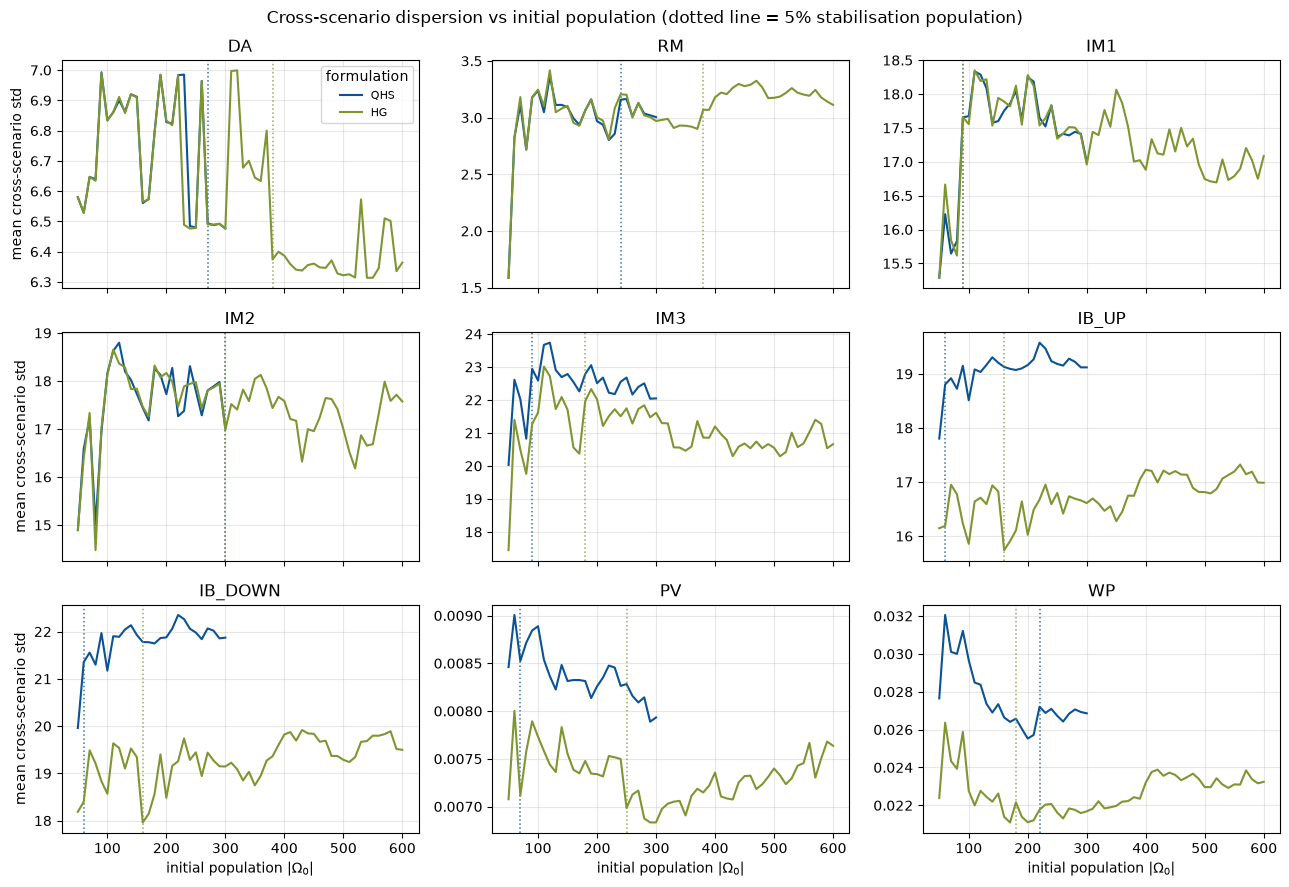

In [24]:
# --- computation -------------------------------------------------------------
dispersion_by_pop = (
    stage_stats.groupby(["dataset", "method", "sc_folder"])["value_std"]
    .mean().reset_index()
)
stabilisation_marks = {
    (m, d): stabilisation_population(dispersion_curve(m, d))
    for d in DATASET_ORDER for m in METHOD_ORDER
}

# --- plotting ----------------------------------------------------------------
SHOW_STABILISATION_MARKS = True

fig, axes = plt.subplots(3, 3, figsize=FIGSIZE_GRID, sharex=True)
for ax, dataset in zip(axes.ravel(), DATASET_ORDER):
    for key in METHOD_ORDER:
        lab = METHOD_LABEL[key]
        sub = dispersion_by_pop[
            (dispersion_by_pop["dataset"] == dataset) & (dispersion_by_pop["method"] == key)
        ].sort_values("sc_folder")
        ax.plot(sub["sc_folder"], sub["value_std"], color=COLORS[lab], lw=1.5, label=lab)
        if SHOW_STABILISATION_MARKS:
            mark = stabilisation_marks[(key, dataset)]
            if not np.isnan(mark):
                ax.axvline(mark, color=COLORS[lab], ls=":", lw=1.1, alpha=0.8)
    ax.set_title(dataset)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel(r"initial population $|\Omega_0|$")
for ax in axes[:, 0]:
    ax.set_ylabel("mean cross-scenario std")
axes[0, 0].legend(title="formulation", fontsize=8)
fig.suptitle("Cross-scenario dispersion vs initial population "
             "(dotted line = 5% stabilisation population)")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_stabilisation_vs_count.png"), dpi=200, bbox_inches="tight")
plt.show()


### Figure `fig:sg-comparison` — `figures/sg_method_comparison`
> *Direct comparison of the two formulations over the overlapping initial-population range.*

### ⚠️ REPRODUCIBLE, but the caption does not specify the content

The caption names no metric, axis or series, so the exact original panels cannot be
recovered from the chapter text. What is built below is the comparison the surrounding
subsection actually argues, entirely from the two CSVs:

1. **QHS excess dispersion by dataset** — the "identical for single-stage prices,
   14–21% higher for the quarter-hourly datasets" result.
2. **Forecast fidelity by dataset** — `abs_bias_tree` for both formulations against the
   generator's own `abs_bias_pred`, the "no comparable separation" result.
3. **Topology ratio vs $|\Omega_0|$** — QHS/HG for nodes and effective scenarios, the
   "5.4× nodes at matched initial population" result.

Swap in different panels freely; the underlying frames are computed separately above.

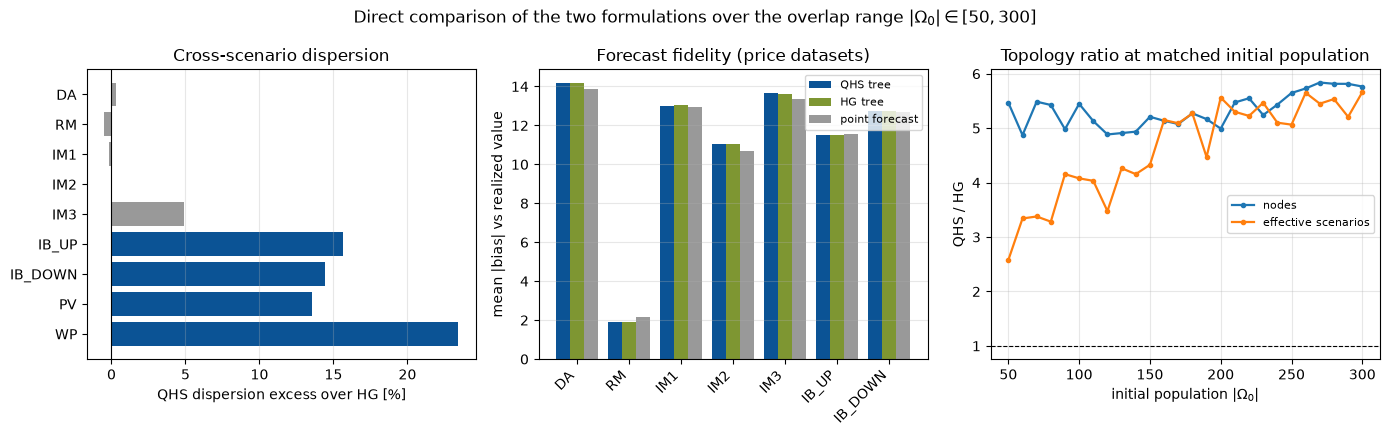

In [25]:
# --- computation -------------------------------------------------------------
comparison_std = sep.copy()                    # from the fidelity section above

comparison_bias = pd.DataFrame({
    "QHS tree": fidelity[("abs_bias_tree", "QHS")],
    "HG tree": fidelity[("abs_bias_tree", "HG")],
    "point forecast": fidelity[("abs_bias_pred", "QHS")],
})

topology_ratio = pd.DataFrame({
    "nodes": (nodes_by_pop["QHS"] / nodes_by_pop["HG"]),
    "effective scenarios": (
        summary.groupby(["method", "sc_folder"])["effective_num_scenarios"].mean()
        .unstack("method").rename(columns=METHOD_LABEL).pipe(lambda d: d["QHS"] / d["HG"])
    ),
}).loc[OVERLAP_MIN:OVERLAP_MAX]

# --- plotting ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

# panel 1: QHS excess dispersion, in percent (datasets have incomparable units)
ax = axes[0]
excess = comparison_std["QHS excess over HG [%]"]
ax.barh(range(len(excess)), excess.values,
        color=["0.6" if v < 5 else COLORS["QHS"] for v in excess.values])
ax.set_yticks(range(len(excess)))
ax.set_yticklabels(excess.index)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("QHS dispersion excess over HG [%]")
ax.set_title("Cross-scenario dispersion")
ax.grid(alpha=0.3, axis="x")

# panel 2: forecast fidelity, absolute units, prices only (PV/WP are ~0 on this scale)
ax = axes[1]
price_sets = [d for d in DATASET_ORDER if d not in ("PV", "WP")]
x = np.arange(len(price_sets))
w = 0.27
ax.bar(x - w, comparison_bias.loc[price_sets, "QHS tree"], w, label="QHS tree",
       color=COLORS["QHS"])
ax.bar(x, comparison_bias.loc[price_sets, "HG tree"], w, label="HG tree",
       color=COLORS["HG"])
ax.bar(x + w, comparison_bias.loc[price_sets, "point forecast"], w,
       label="point forecast", color="0.6")
ax.set_xticks(x)
ax.set_xticklabels(price_sets, rotation=45, ha="right")
ax.set_ylabel("mean |bias| vs realized value")
ax.set_title("Forecast fidelity (price datasets)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

# panel 3: topology ratio across the overlap range
ax = axes[2]
for col in topology_ratio.columns:
    ax.plot(topology_ratio.index, topology_ratio[col], lw=1.6, marker="o", ms=3, label=col)
ax.axhline(1.0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"initial population $|\Omega_0|$")
ax.set_ylabel("QHS / HG")
ax.set_title("Topology ratio at matched initial population")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Direct comparison of the two formulations over the overlap range "
             r"$|\Omega_0| \in [50, 300]$")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "sg_method_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()


---
## 5.1.4 — Scenario sets selected for each experiment
`\label{subsec:results-scenario-selection}`

### Table `tab:selected-sets`
> *Scenario sets used in the equal-retained-count comparison. Where more than one QHS
> configuration yields the same retained count, the larger initial population is used.*

**Recomputed for the Nov-2025 regeneration.** The published table's counts
($|\Omega| \in \{55, 76, 108, 146\}$) came from the old scenario-generation run;
regenerating with the Nov 1-30, 2025 data and a fixed seed produces a different set of
common retained counts, $|\Omega| \in \{46, 51, 60, 130, 141\}$, found the same way
(day-1 configurations whose `num_leaf_nodes` matches, tie-break = largest
$|\Omega_0|$). The only tie is now at $|\Omega| = 130$, where HG attains it at both
$|\Omega_0| = 380$ and $480$ and the table takes 480 (QHS has no ties in this set).

In [26]:
# --- computation -------------------------------------------------------------
# The four retained counts achieved by a converged run of BOTH formulations.
COMMON_RETAINED_COUNTS = [46, 51, 60, 130, 141]  # recomputed for the Nov-2025 regeneration (was [55, 76, 108, 146])

def configs_for_retained(count):
    """All day-1 (method, |Omega_0|) pairs whose retained count equals `count`."""
    hit = day1[day1["num_leaf_nodes"] == count]
    return {METHOD_LABEL[m]: sorted(g["sc_folder"]) for m, g in hit.groupby("method")}

# report the ties before collapsing them, so the tie-break stays visible
for c in COMMON_RETAINED_COUNTS:
    print(f"|Omega| = {c:3d} ->", configs_for_retained(c))

rows = []
for count in COMMON_RETAINED_COUNTS:
    row = {"|Omega|": count}
    for lab, pops in configs_for_retained(count).items():
        chosen = max(pops)          # caption's tie-break: the larger initial population
        row[f"{lab} |Omega_0|"] = chosen
        row[f"{lab} rho"] = count / chosen
    rows.append(row)

selected_sets = pd.DataFrame(rows).set_index("|Omega|")[
    ["QHS |Omega_0|", "QHS rho", "HG |Omega_0|", "HG rho"]
]
selected_sets.round(3)

|Omega| =  46 -> {'QHS': [50], 'HG': [110]}
|Omega| =  51 -> {'QHS': [60], 'HG': [120]}
|Omega| =  60 -> {'QHS': [70], 'HG': [140]}
|Omega| = 130 -> {'QHS': [150], 'HG': [380, 480]}
|Omega| = 141 -> {'QHS': [170], 'HG': [440]}


,QHS |Omega_0|,QHS rho,HG |Omega_0|,HG rho
|Omega|,,,,
46,50,0.920,110,0.418
51,60,0.850,120,0.425
60,70,0.857,140,0.429
130,150,0.867,480,0.271
141,170,0.829,440,0.320


The deep-dive comparisons of Sections `subsec:results-optimized-values` and
`subsec:results-vss-formulations` used the largest of these, $|\Omega| = 146$, from
$|\Omega_0| = 170$ (QHS) and $|\Omega_0| = 560$ (HG), under the old scenario-generation
run. With the Nov-2025 regeneration the largest common retained count is
$|\Omega| = 141$, still from $|\Omega_0| = 170$ (QHS) but now $|\Omega_0| = 440$ (HG)
-- the deep-dive configuration would need to be re-run at this new matched pair for the
comparison to stay apples-to-apples.

The **secondary comparison** at equal initial population uses
$|\Omega_0| \in \{50, 60, \ldots, 170\}$ — the same range as `tab:retention` above, which
already lists every configuration in it.

---
## Coverage summary

| # | Item | Label | Status |
|---|---|---|---|
| 1 | Retention table | `tab:retention` | ✅ reproducible |
| 2 | Tree topology & probability concentration | `tab:tree-topology` | ✅ reproducible |
| 3 | Topology vs initial population | `fig:sg-topology` | ✅ reproducible |
| 4 | Stage-by-stage branching profile | `fig:sg-branching` | ✅ reproducible *(needs the JSON export)* |
| 5 | Post-reduction probability distribution | `fig:sg-prob` | ✅ reproducible *(needs the JSON export)* |
| 6 | Retained trajectories, DA and WP | `fig:sg-fans` | ✅ reproducible *(needs the JSON export)* |
| 7 | Dispersion & forecast fidelity by dataset | `tab:tree-fidelity` | ✅ reproducible |
| 8 | Dispersion stabilisation population | `tab:stabilisation` | ✅ reproducible |
| 9 | Dispersion vs initial population | `fig:sg-stabilisation` | ✅ reproducible |
| 10 | Direct method comparison | `fig:sg-comparison` | ✅ reproducible (caption specifies no content; panels reconstructed from the subsection's claims) |
| 11 | Selected scenario sets | `tab:selected-sets` | ✅ reproducible |
| 12 | Retained vs initial population, both formulations | `fig:sg-retention` | ✅ new -- not in the published chapter, added for visual inspection |

Every item in Section 5.1 now renders. Items 4–6 are built from the two generator exports
(`QHG_sc100_results_1.json`, `HG_sc100_results_1.json`) rather than the CSVs, which keep
only summary statistics; each derived quantity is cross-checked against the corresponding
`scenario_tree_summary.csv` row in section 0.1 before use.

To render items 4–6 at a different configuration, drop in the matching
`results_<day>.json` for both formulations and repoint `TREE_FILES` (and `REP_FOLDER` /
`REP_DAY`, which only label the plots). The source files are named by the `path` column of
the summary CSV: `.../{dif_ren,same_ren}_scentree/scenariotree_<N>/results_<day>.json`.

---

## What is a single day, and what is not

Worth keeping in view when reading these outputs together, because the section mixes three
different bases:

| Basis | Items |
|---|---|
| **One tree** ($\lvert\Omega_0\rvert = 100$, day 1) | `fig:sg-branching`, `fig:sg-prob`, `fig:sg-fans` |
| **Day 1 only**, across all populations | `tab:retention`, `tab:selected-sets` |
| **Averaged over all 30 days** | `tab:tree-topology`, `tab:tree-fidelity`, `tab:stabilisation`, `fig:sg-topology`, `fig:sg-stabilisation`, `fig:sg-comparison` |

The three per-tree figures are openly labelled representative in the chapter. The two
day-1 tables are not: the section preamble states that results are *"aggregated over the
30 days, so that each initial-population size is represented by a single outcome"*, which
holds for the six aggregated items but not for these two. Day 1 is nonetheless the correct
basis for them, since day 1 is the tree that was actually solved — it is the wording that
needs adjusting, not the numbers.

This matters quantitatively: HG's retained count carries 8.0% day-to-day scatter
(QHS 3.7%), and the five matched counts $\{46, 51, 60, 130, 141\}$ underpinning the
equal-retained-count design exist **only** on day 1 — day 2 yields
$\{66, 92, 121, 135, 149\}$ instead. The cell below quantifies both.
(Figures recomputed for the Nov-2025 regeneration; were 13.4%/4.2% and
$\{55, 76, 108, 146\}$ / $\{75, 89, 115, 153, 155, 217\}$ under the old run.)

In [27]:
# --- how much of the day-1 design is specific to day 1? ----------------------
retained_by_day = summary.groupby(["method", "sc_folder"])["num_leaf_nodes"]
scatter = (retained_by_day.std() / retained_by_day.mean() * 100).groupby("method").mean()
print("mean day-to-day scatter of the retained count (std as % of mean):")
for m, v in scatter.items():
    print(f"  {METHOD_LABEL[m]:4s} {v:.1f}%")

common_counts_per_day = []
for d in sorted(summary["day"].unique()):
    day_slice = summary[summary["day"] == d]
    q = set(day_slice[day_slice["method"] == "dif_ren"]["num_leaf_nodes"])
    h = set(day_slice[day_slice["method"] == "same_ren"]["num_leaf_nodes"])
    common_counts_per_day.append({
        "day": d,
        "n_common_counts": len(q & h),
        "chapter set available": sorted(set(COMMON_RETAINED_COUNTS) & q & h),
    })

common_counts_per_day = pd.DataFrame(common_counts_per_day).set_index("day")
print(f"\nmean common retained counts per day: "
      f"{common_counts_per_day['n_common_counts'].mean():.1f}")
common_counts_per_day.head(8)

mean day-to-day scatter of the retained count (std as % of mean):
  QHS  3.7%
  HG   8.0%

mean common retained counts per day: 4.5


,n_common_counts,chapter set available
day,,
1,5,"[46, 51, 60, 130, 141]"
2,5,[]
3,4,[]
4,6,[46]
5,6,[]
6,5,[]
7,2,[]
8,6,[]
